<a href="https://colab.research.google.com/github/Harshini-Suresha/Plant_classification/blob/main/test_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tensorflow keras opencv-python matplotlib

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
!pip install tensorflow==2.13.0

In [ ]:
from tensorflow import keras
loaded_model = keras.models.load_model('/content/drive/MyDrive/saved model.hdf5')

The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


In [ ]:
test_dir = '/content/drive/MyDrive/test images/test images'

img_width, img_height = 150, 150
batch_size = 32

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 298 images belonging to 5 classes.


In [ ]:
predictions = loaded_model.predict(test_generator)

10/10 [==============================] - 66s 6s/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Get true labels
true_labels = test_generator.classes

# Get predicted labels
predicted_labels = np.argmax(predictions, axis=1)

# Calculate metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')
f1 = f1_score(true_labels, predicted_labels, average='weighted')
conf_matrix = confusion_matrix(true_labels, predicted_labels)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Confusion Matrix:\n', conf_matrix)

Accuracy: 0.1912751677852349
Precision: 0.036586189811269765
Recall: 0.1912751677852349
F1-score: 0.061423575007089525
Confusion Matrix:
 [[57  0  0  0  0]
 [34  0  0  0  0]
 [22  0  0  0  0]
 [97  0  0  0  0]
 [88  0  0  0  0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


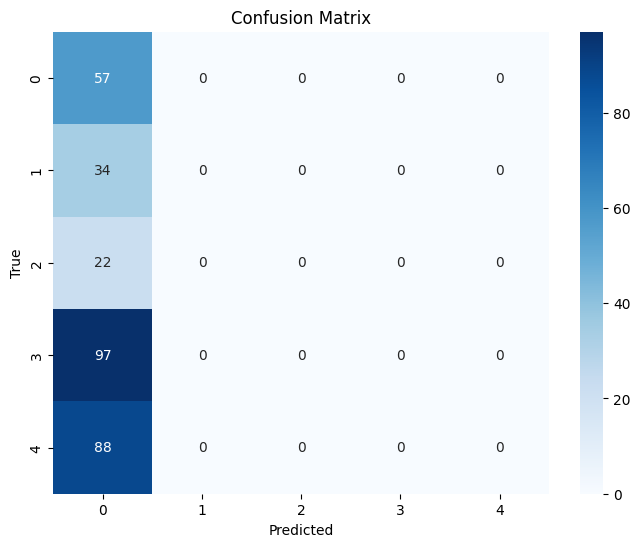

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
train_dir = '/content/drive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model'

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1285 images belonging to 5 classes.


41/41 [==============================] - 224s 5s/step
Training Metrics:
Accuracy: 0.2272373540856031
Precision: 0.05163681509182577
Recall: 0.2272373540856031
F1-score: 0.08415130931261397
Confusion Matrix:
 [[292   0   0   0   0]
 [166   0   0   0   0]
 [254   0   0   0   0]
 [470   0   0   0   0]
 [103   0   0   0   0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


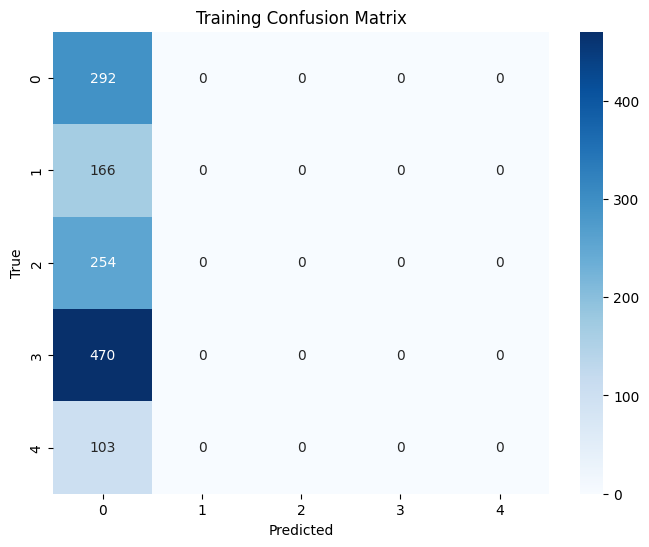

In [ ]:
train_predictions = loaded_model.predict(train_generator)

train_true_labels = train_generator.classes


train_predicted_labels = np.argmax(train_predictions, axis=1)


train_accuracy = accuracy_score(train_true_labels, train_predicted_labels)
train_precision = precision_score(train_true_labels, train_predicted_labels, average='weighted')
train_recall = recall_score(train_true_labels, train_predicted_labels, average='weighted')
train_f1 = f1_score(train_true_labels, train_predicted_labels, average='weighted')
train_conf_matrix = confusion_matrix(train_true_labels, train_predicted_labels)

print("Training Metrics:")
print(f'Accuracy: {train_accuracy}')
print(f'Precision: {train_precision}')
print(f'Recall: {train_recall}')
print(f'F1-score: {train_f1}')
print('Confusion Matrix:\n', train_conf_matrix)


plt.figure(figsize=(8, 6))
sns.heatmap(train_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Training Confusion Matrix')
plt.show()

In [ ]:
print("Comparison:")
print(f"Training Accuracy: {train_accuracy}")
print(f"Test Accuracy: {accuracy}")
print(f"Training F1-score: {train_f1}")
print(f"Test F1-score: {f1}")


Comparison:
Training Accuracy: 0.2272373540856031
Test Accuracy: 0.1912751677852349
Training F1-score: 0.08415130931261397
Test F1-score: 0.061423575007089525


In [ ]:
train_dir = '/content/drive/MyDrive/Cast iron, Date Palm, ArecaNut, Bird of Paradise and Monstera deliciosa classification model'

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1285 images belonging to 5 classes.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import load_img, img_to_array


class_names = list(test_generator.class_indices.keys())

def display_prediction(image_path, true_label, predicted_label):
    img = load_img(image_path, target_size=(img_width, img_height))
    img_array = img_to_array(img) / 255.0
    plt.imshow(img_array)
    plt.title(f"True: {true_label}, Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()

In [ ]:
predictions = loaded_model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = test_generator.classes

correct_predictions = []
incorrect_predictions = []

filenames = test_generator.filenames

for i in range(len(true_labels)):
    true_label = class_names[true_labels[i]]
    predicted_label = class_names[predicted_labels[i]]

    import os
    image_path = os.path.join(test_dir, filenames[i])

    if true_label == predicted_label:
        correct_predictions.append((image_path, true_label, predicted_label))
    else:
        incorrect_predictions.append((image_path, true_label, predicted_label))

10/10 [==============================] - 45s 5s/step


Correct Predictions:


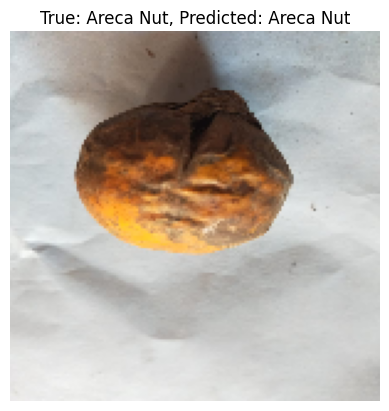

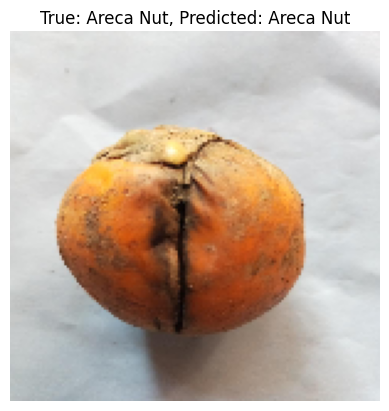

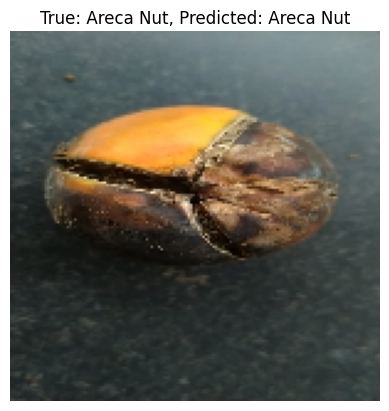


Incorrect Predictions:


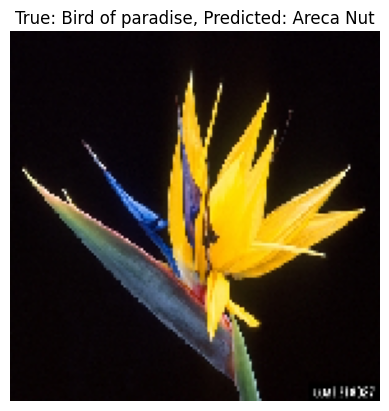

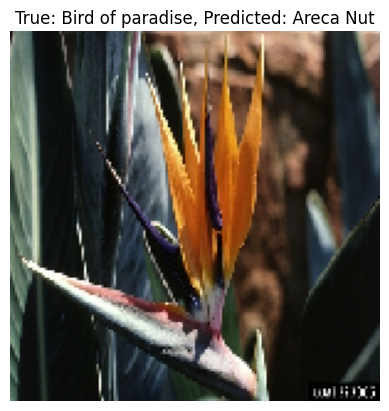

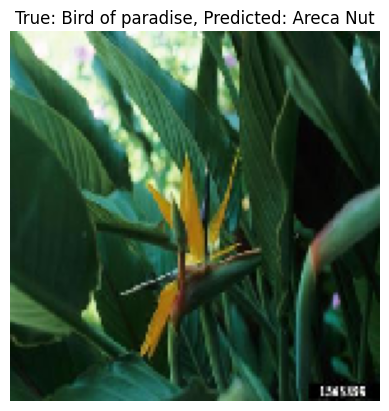


Misclassifications of ClassA as ClassB:


In [ ]:
print("Correct Predictions:")
num_examples = 3
for i in range(min(num_examples, len(correct_predictions))):
    image_path, true_label, predicted_label = correct_predictions[i]
    display_prediction(image_path, true_label, predicted_label)

print("\nIncorrect Predictions:")
for i in range(min(num_examples, len(incorrect_predictions))):
    image_path, true_label, predicted_label = incorrect_predictions[i]
    display_prediction(image_path, true_label, predicted_label)

target_true_class = "ClassA"
target_predicted_class = "ClassB"

specific_misclassifications = [
    (image_path, true_label, predicted_label)
    for image_path, true_label, predicted_label in incorrect_predictions
    if true_label == target_true_class and predicted_label == target_predicted_class
]

print(f"\nMisclassifications of {target_true_class} as {target_predicted_class}:")
for image_path, true_label, predicted_label in specific_misclassifications[:min(num_examples, len(specific_misclassifications))]:
    display_prediction(image_path, true_label, predicted_label)

In [ ]:
loaded_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 518, 518, 3)          0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 256, 256, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 256, 256, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                        

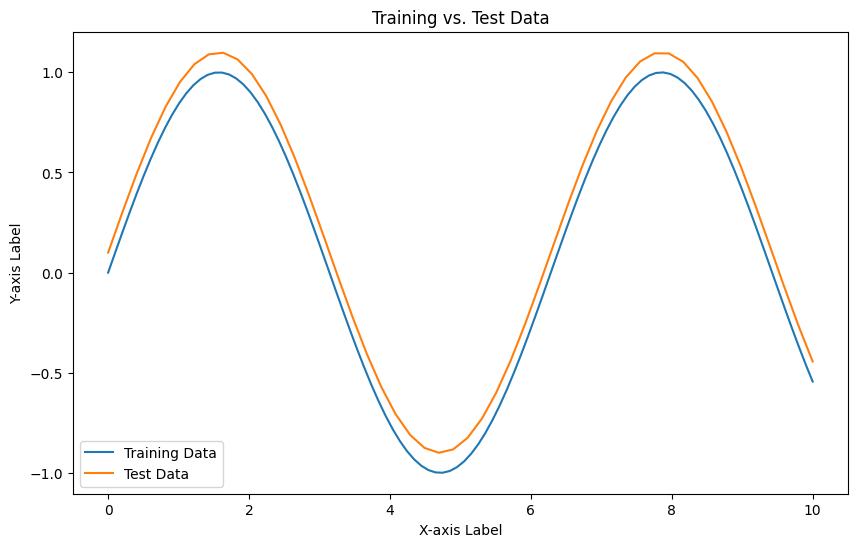

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_train = np.linspace(0, 10, 100)
y_train = np.sin(x_train)
x_test = np.linspace(0, 10, 50)
y_test = np.sin(x_test) + 0.1

plt.figure(figsize=(10, 6))
plt.plot(x_train, y_train, label='Training Data')
plt.plot(x_test, y_test, label='Test Data')

plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Training vs. Test Data')
plt.legend()
plt.show()


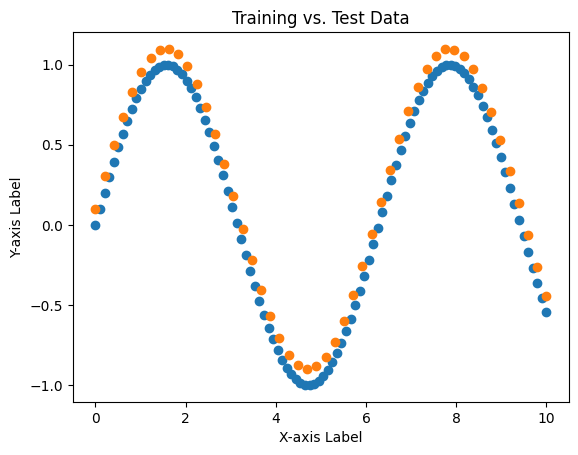

In [ ]:
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Training vs. Test Data')

plt.scatter(x_train, y_train, label='Training Data')
plt.scatter(x_test, y_test, label='Test Data')

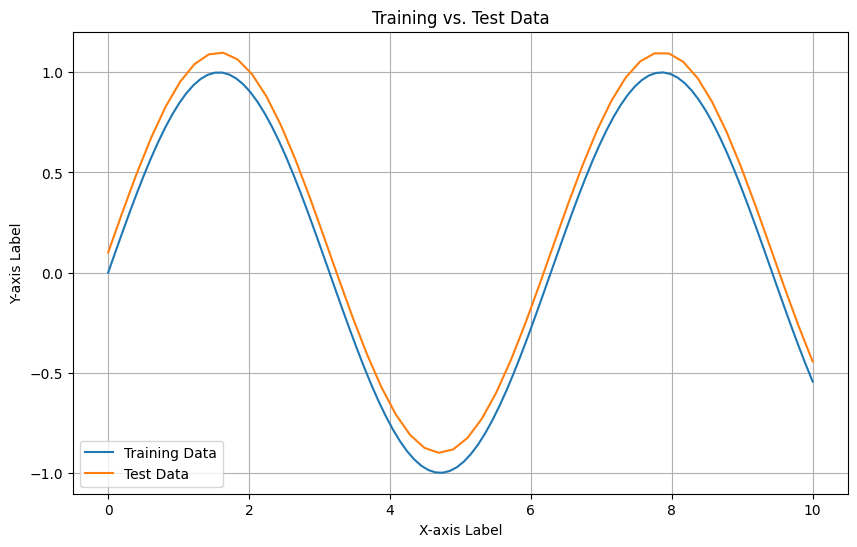

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_train = np.linspace(0, 10, 100)
y_train = np.sin(x_train)
x_test = np.linspace(0, 10, 50)
y_test = np.sin(x_test) + 0.1

plt.figure(figsize=(10, 6))
plt.plot(x_train, y_train, label='Training Data')
plt.plot(x_test, y_test, label='Test Data')

plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Training vs. Test Data')
plt.legend()

# Add grid with higher zorder
plt.grid(True, zorder=0)  # zorder=0 ensures grid is behind data points

plt.show()

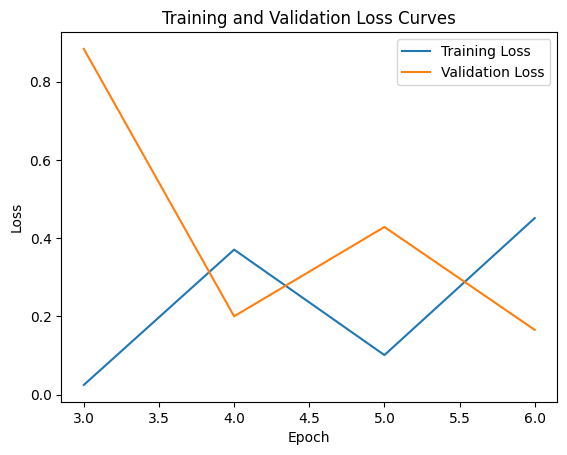

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


epochs = range(3, 7)  # Example: 10 epochs
train_loss = [np.random.rand() for _ in epochs]
val_loss = [np.random.rand() for _ in epochs]

# Now you can plot the loss curves:
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

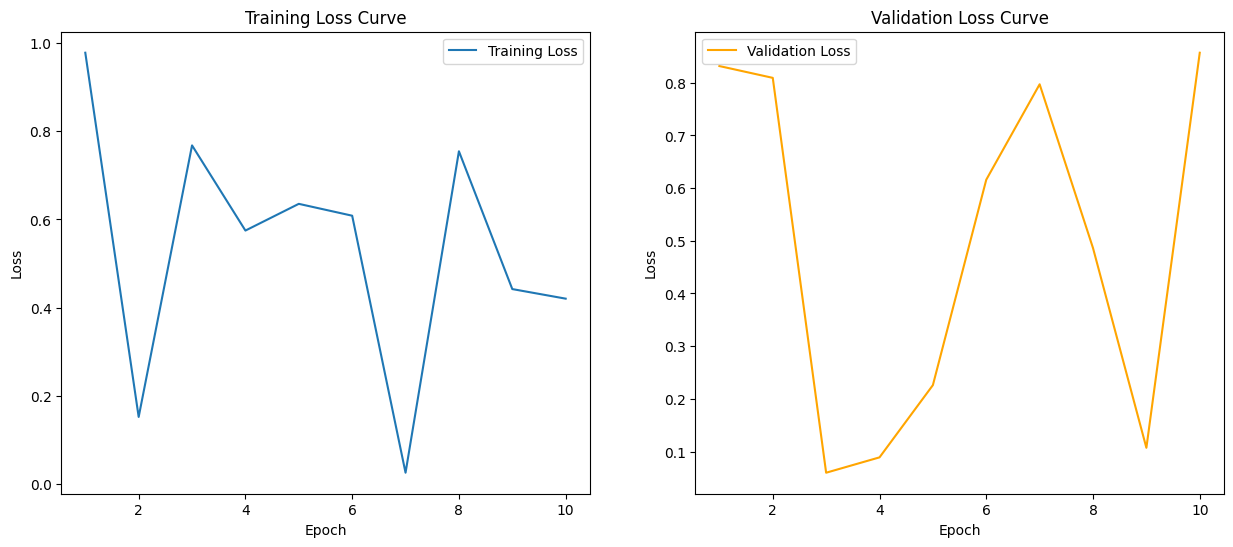

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, 11)  # Example: 10 epochs
train_loss = [np.random.rand() for _ in epochs]
val_loss = [np.random.rand() for _ in epochs]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot training data on the first subplot
ax1.plot(epochs, train_loss, label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Curve')
ax1.legend()

# Plot validation (test) data on the second subplot
ax2.plot(epochs, val_loss, label='Validation Loss', color='orange')  # Different color for clarity
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss Curve')
ax2.legend()

plt.show()

**ResNet50 model**

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model


img_width, img_height = 150, 150

# Load pre-trained ResNet50
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(img_width, img_height, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

loss, accuracy = model.evaluate(test_generator)
print(f'Test accuracy: {accuracy}')

94765736/94765736 [==============================] - 0s 0us/step
Epoch 1/10
41/41 [==============================] - 202s 5s/step - loss: 2.2251 - accuracy: 0.2506 - val_loss: 1.4524 - val_accuracy: 0.3725
Epoch 2/10
41/41 [==============================] - 196s 5s/step - loss: 1.6826 - accuracy: 0.3922 - val_loss: 2.1278 - val_accuracy: 0.3020
Epoch 3/10
41/41 [==============================] - 192s 5s/step - loss: 1.5788 - accuracy: 0.4016 - val_loss: 1.9641 - val_accuracy: 0.3792
Epoch 4/10
41/41 [==============================] - 205s 5s/step - loss: 1.5881 - accuracy: 0.4233 - val_loss: 1.7375 - val_accuracy: 0.3725
Epoch 5/10
41/41 [==============================] - 194s 5s/step - loss: 1.4696 - accuracy: 0.4140 - val_loss: 1.5932 - val_accuracy: 0.3591
Epoch 6/10
41/41 [==============================] - 195s 5s/step - loss: 1.4244 - accuracy: 0.3689 - val_loss: 1.4684 - val_accuracy: 0.3221
Epoch 7/10
41/41 [==============================] - 191s 5s/step - loss: 1.4391 - accurac